<a href="https://colab.research.google.com/github/kursatkara/MAE_5020_Spring_2026/blob/master/04_01_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression for Aerospace Applications

In aerospace engineering, estimating aerodynamic derivatives from wind tunnel data is a common task. For instance, estimating the lift curve slope ($C_{L_\alpha}$) from measured lift coefficients ($C_L$) at various angles of attack ($\alpha$).

Sensors, force balances, and data acquisition systems are susceptible to noise and anomalies (e.g., occasional outlier readings). Therefore, robust regression techniques are necessary. We compare three error norms for fitting a line $f(x) = mx + c$ to our data $(x_i, y_i)$:

1. **$L_\infty$ norm (Maximum Error):** Minimizes the maximum residual.
   $$ \text{Error} = \max_i |f(x_i) - y_i| $$
   *Highly sensitive to outliers.*

2. **$L_1$ norm (Mean Absolute Error):** Minimizes the sum of absolute errors.
   $$ \text{Error} = \sum_i |f(x_i) - y_i| $$
   *Very robust to outliers.*

3. **$L_2$ norm (Least Squares Error):** Minimizes the sum of squared errors.
   $$ \text{Error} = \sum_i (f(x_i) - y_i)^2 $$
   *Standard approach, but moderately sensitive to outliers.*

The code from the textbook [1] was modified and enhanced for this context.

[1] https://github.com/kursatkara/databook_python/blob/master/CH04/CH04_SEC01_LinearRegression.ipynb

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize
from matplotlib import rcParams

# Set plotting defaults for clarity
rcParams['figure.figsize'] = [8, 6]
rcParams.update({'font.size': 12})
rcParams['axes.grid'] = True

# Function definitions for linear fit: y = m*x + c
# We optimize parameters x0 = [m, c], such that f(x) = m*x + c approximates y.
# The objective function mx + c - y = 0 is minimized according to different norms.

def fit1(x0, t):
    """
    L_inf norm: Maximum absolute error.
    Minimizes the maximum distance from any data point to the line.

    Args:
        x0 (list or np.array): Parameters [slope, intercept].
        t (tuple): Tuple of (x_data, y_data).

    Returns:
        float: Maximum absolute error.
    """
    x, y = t
    return np.max(np.abs(x0[0]*x + x0[1] - y))

def fit2(x0, t):
    """
    L_1 norm: Mean absolute error.
    Minimizes the sum of absolute distances from data points to the line.

    Args:
        x0 (list or np.array): Parameters [slope, intercept].
        t (tuple): Tuple of (x_data, y_data).

    Returns:
        float: Sum of absolute errors.
    """
    x, y = t
    return np.sum(np.abs(x0[0]*x + x0[1] - y))

def fit3(x0, t):
    """
    L_2 norm: Least squares error.
    Minimizes the sum of squared distances from data points to the line.

    Args:
        x0 (list or np.array): Parameters [slope, intercept].
        t (tuple): Tuple of (x_data, y_data).

    Returns:
        float: Sum of squared errors.
    """
    x, y = t
    return np.sum((x0[0]*x + x0[1] - y)**2)

Data (alpha_deg, CL_measured):
 (array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]), array([0.2, 0.5, 0.3, 3.5, 1. , 1.5, 1.8, 2. , 2.3, 2.2]))
Optimization terminated successfully.
         Current function value: 1.464330
         Iterations: 52
         Function evaluations: 98
Optimization terminated successfully.
         Current function value: 3.640022
         Iterations: 64
         Function evaluations: 126
Optimization terminated successfully.
         Current function value: 6.234182
         Iterations: 49
         Function evaluations: 92

--- Regression Results ---
Line fits for L_inf (Maximum Error) : slope=0.2714, intercept=0.9503
Line fits for L_1 (Mean Abs Error)  : slope=0.2600, intercept=-0.0600
Line fits for L_2 (Least Sq Error)  : slope=0.2091, intercept=0.3800


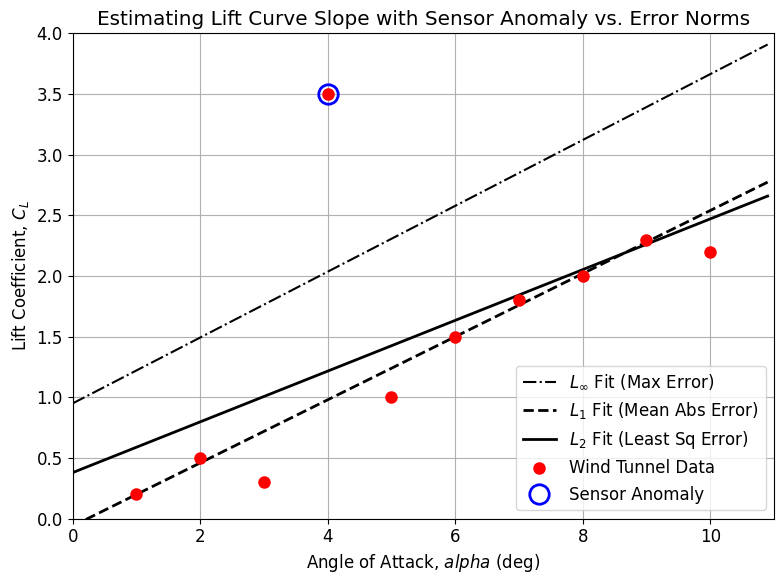

In [3]:
# Wind Tunnel Data (Angle of Attack vs. Lift Coefficient)
alpha_deg = np.arange(1, 11) # Angle of Attack (degrees)

# Measured Lift Coefficients (C_L)
CL_measured = np.array([0.2, 0.5, 0.3, 3.5, 1.0, 1.5, 1.8, 2.0, 2.3, 2.2])

# NOTE: At alpha = 4 degrees, CL_measured[3] = 3.5 is an obvious sensor anomaly (outlier).
# A physical lift coefficient of 3.5 at 4 degrees alpha is non-physical for most airfoils.
# Uncomment the line below to see the results without the anomaly:
# CL_measured = np.array([0.2, 0.5, 0.3, 0.8, 1.0, 1.5, 1.8, 2.0, 2.3, 2.2])

t = (alpha_deg, CL_measured)
print("Data (alpha_deg, CL_measured):\n", t)

# Initial guess for optimization: [slope, intercept]
x0 = np.array([1.0, 1.0])

# Minimize the objective functions using the downhill simplex algorithm.
# scipy.optimize.fmin finds the minimum of a function.
p1 = scipy.optimize.fmin(fit1, x0, args=(t,))
p2 = scipy.optimize.fmin(fit2, x0, args=(t,))
p3 = scipy.optimize.fmin(fit3, x0, args=(t,))

print("\n--- Regression Results ---")
print(f"Line fits for L_inf (Maximum Error) : slope={p1[0]:.4f}, intercept={p1[1]:.4f}")
print(f"Line fits for L_1 (Mean Abs Error)  : slope={p2[0]:.4f}, intercept={p2[1]:.4f}")
print(f"Line fits for L_2 (Least Sq Error)  : slope={p3[0]:.4f}, intercept={p3[1]:.4f}")

# Generate dense x-coordinates for smooth line plotting
alpha_fine = np.arange(0, 11, 0.1)

# Evaluate the fitted polynomials (degree 1) at the fine grid
CL_fit_Linf = np.polyval(p1, alpha_fine)
CL_fit_L1   = np.polyval(p2, alpha_fine)
CL_fit_L2   = np.polyval(p3, alpha_fine)

# Plotting the results
plt.figure()

# Plot the fits
plt.plot(alpha_fine, CL_fit_Linf, '-.', color='k', label=r'$L_{\infty}$ Fit (Max Error)')
plt.plot(alpha_fine, CL_fit_L1, '--', color='k', linewidth=2, label=r'$L_{1}$ Fit (Mean Abs Error)')
plt.plot(alpha_fine, CL_fit_L2, color='k', linewidth=2, label=r'$L_{2}$ Fit (Least Sq Error)')

# Plot the experimental data
plt.plot(alpha_deg, CL_measured, 'o', color='r', markersize=8, label='Wind Tunnel Data')
# Highlight the outlier
plt.plot(alpha_deg[3], CL_measured[3], 'o', color='None', markeredgecolor='b', markersize=14, markeredgewidth=2, label='Sensor Anomaly')

plt.ylim(0, 4)
plt.xlim(0, 11)
plt.xlabel(r'Angle of Attack, $alpha$ (deg)')
plt.ylabel(r'Lift Coefficient, $C_L$')
plt.title('Estimating Lift Curve Slope with Sensor Anomaly vs. Error Norms')
plt.legend()
plt.tight_layout()
plt.show()

### Challenge Problem: Robust Regression with RANSAC
In realistic wind tunnel testing, sensors don't just produce single anomalies; they can produce clustered outliers (e.g., flow separation buffet). Standard L1/L2 norms might still be dragged off-course. Your challenge is to apply the **RANSAC (RANdom SAmple Consensus)** algorithm to robustly estimate the lift curve slope even when 30% of your data points are severe outliers.

In [ ]:
# YOUR CODE HERE
# 1. Generate new data with 30% outliers
# 2. Fit a standard Least Squares model
# 3. Fit a RANSACRegressor from sklearn.linear_model
# 4. Plot both lines against the dataset
import numpy as np
from sklearn.linear_model import RANSACRegressor, LinearRegression
import matplotlib.pyplot as plt
# ...

<details>
<summary><b>Click to Reveal Solution</b></summary>

```python
import numpy as np
from sklearn.linear_model import RANSACRegressor, LinearRegression
import matplotlib.pyplot as plt

# 1. Generate data
np.random.seed(42)
alpha = np.arange(0, 20, 0.5)
CL = 0.1 * alpha + 0.2 + np.random.normal(0, 0.05, len(alpha))

# Add 30% outliers
n_outliers = int(0.3 * len(alpha))
outlier_indices = np.random.choice(len(alpha), n_outliers, replace=False)
CL[outlier_indices] += np.random.normal(2, 0.5, n_outliers)

X = alpha.reshape(-1, 1)

# 2. Fit Standard L2
lr = LinearRegression()
lr.fit(X, CL)

# 3. Fit RANSAC
ransac = RANSACRegressor(random_state=42)
ransac.fit(X, CL)

# 4. Plotting
plt.figure(figsize=(10, 6))
plt.scatter(alpha, CL, color='gray', label='Wind Tunnel Data (with Outliers)')
plt.plot(alpha, lr.predict(X), color='red', linestyle='--', label='Standard L2 Fit (Skewed)')
plt.plot(alpha, ransac.predict(X), color='blue', linewidth=2, label='RANSAC Robust Fit')
plt.legend()
plt.xlabel('Angle of Attack (deg)')
plt.ylabel('Lift Coefficient')
plt.title('RANSAC vs Standard Regression on Heavily Corrupted Data')
plt.grid(True)
plt.show()
```
</details>